# Zomato Data Analysis Project

## Importing Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Create the data frame

In [17]:
df = pd.read_csv('Zomato_data.csv') 

In [18]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


# coverting the datatypes of column- rate

In [19]:
def handleRate(value):
    value = str(value).split("/")
    value = value[0];
    return float(value)
    
df['rate'] = df['rate'].apply(handleRate)
print(df.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


# What types of restaurant do the majority of customers order from ? 

Text(0.5, 0, 'types of resturant')

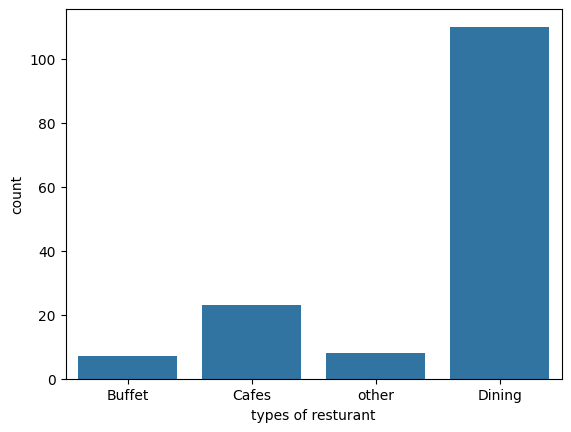

In [22]:
sns.countplot(x=df['listed_in(type)'], data=df)
plt.xlabel('types of resturant')

conclusion - majority of the resturant falls in dining category

# How many votes has each type of restaurant received from customers ?

Text(0, 0.5, 'votes')

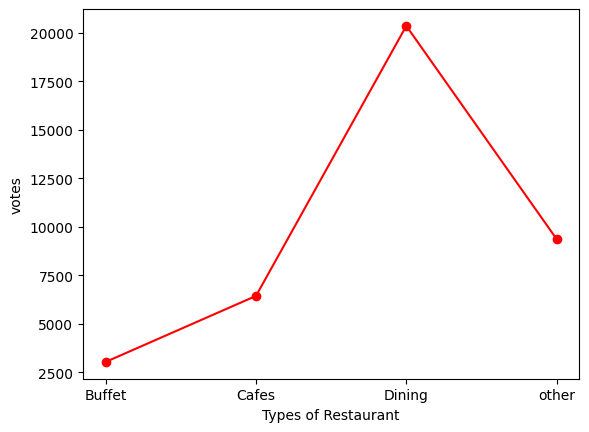

In [23]:
group_data= df.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': group_data})
plt.plot(result, c='red', marker= 'o')
plt.xlabel('Types of Restaurant')
plt.ylabel('votes')

conclusion - Dining resturants has recieved maximum votes

# What are the rating that the majority of resturants recieved from customers?

In [24]:
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3,0,100,Dining
144,New Indraprasta,No,No,3.3,0,150,Dining
145,Anna Kuteera,Yes,No,4.0,771,450,Dining
146,Darbar,No,No,3.0,98,800,Dining


Text(0.5, 0, 'Rating Distribution')

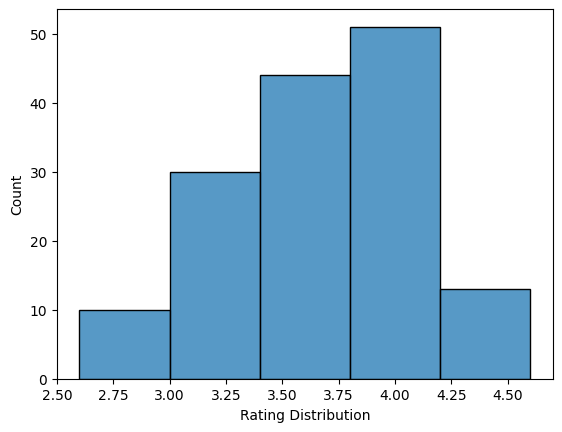

In [25]:
sns.histplot(data=df['rate'],bins=5)
plt.xlabel('Rating Distribution')

conclusion - the majority resturants has received ratings from 3.5 to 4

# Zomato has observed that most couples order most of their food online. What is their average spending on each order ?

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

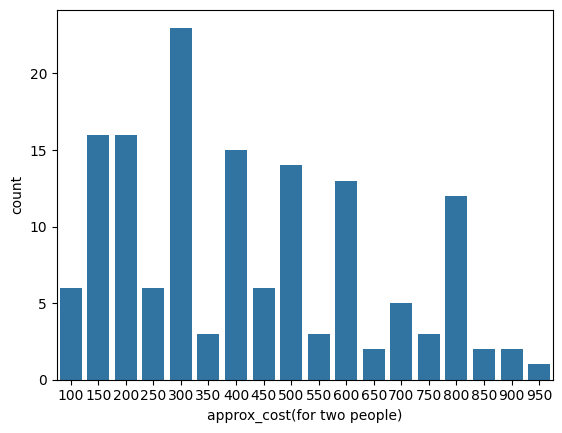

In [27]:
sns.countplot(x=df['approx_cost(for two people)'], data=df)

conclusion - the majority of couple preferr resturants with an approximate cost of 300 rupees

# Which mode (online or offline) has received the maximum rating?

<Axes: xlabel='online_order', ylabel='rate'>

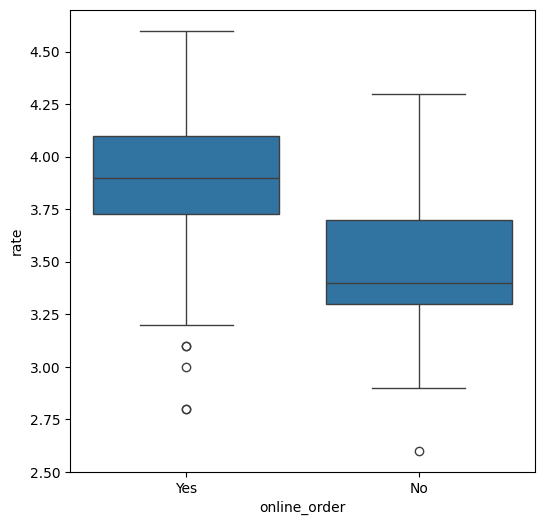

In [28]:
plt.figure(figsize = (6,6))
sns.boxplot(x=df['online_order'],y='rate', data=df)

conclusion - offline order received lower rating in comparision to online order

## Which type of restaurant received more offline orders, so that Zomato can provide customer with some good offers?

In [29]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


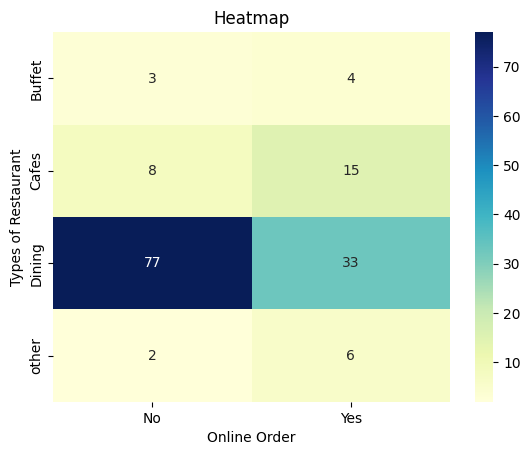

In [30]:
pivot_table = df.pivot_table(values='rate', index='listed_in(type)', columns='online_order', aggfunc= 'size', fill_value=0)
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel('Online Order')
plt.ylabel('Types of Restaurant')
plt.title('Heatmap')
plt.show()

conclusion - Dining Restaurants Primarily accept offline orders, whereas cafes primarily receive online orders. This suggests that clients prefers orders in person at restaurants, but prefer online ordering at cafes.